In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, 
                            confusion_matrix, 
                            ConfusionMatrixDisplay)

In [54]:
RANDOM_STATE = 42

In [55]:
df = pd.read_csv('defaults.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [56]:
print(df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())

ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

Missing values: 0


In [57]:
df.drop(columns=["ID"], inplace=True)

In [72]:
df.rename(columns={"default payment next month": "default"}, inplace=True)
print("\nRenamed 'default payment next month' = 'default'")

df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
print("\nEDUCATION value counts after fix:")
print(df["EDUCATION"].value_counts().sort_index())

pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
df[pay_cols] = df[pay_cols].replace({-2: -1})
print("\nPAY_0 unique values after fix:", sorted(df["PAY_0"].unique()))

assert df.isnull().sum().sum() == 0, "Unexpected nulls found!"
print("\nNo missing values. Dataset is clean.")
print("Final shape:", df.shape)



Renamed 'default payment next month' = 'default'

EDUCATION value counts after fix:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

PAY_0 unique values after fix: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

No missing values. Dataset is clean.
Final shape: (30000, 24)



Class distribution:
 default
0    23364
1     6636
Name: count, dtype: int64


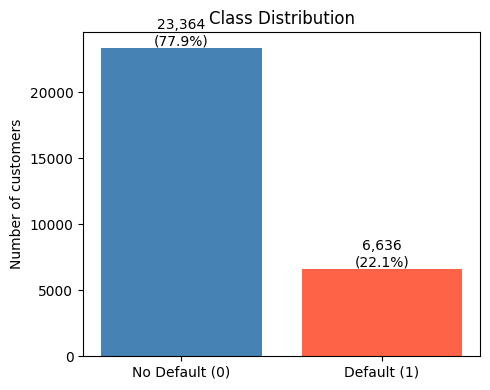


Class imbalance ratio: 3.5:1 (no-default : default)


In [59]:
counts = df["default"].value_counts().sort_index()
print("\nClass distribution:\n", counts)
 
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["No Default (0)", "Default (1)"], counts.values, color=["steelblue", "tomato"])
ax.set_ylabel("Number of customers")
ax.set_title("Class Distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=150)
plt.show()
 
print(f"\nClass imbalance ratio: {counts[0]/counts[1]:.1f}:1 (no-default : default)")

In [60]:
feature_cols = [c for c in df.columns if c != "default"]
X = df[feature_cols]
y = df["default"]
 
print("\nFeature matrix shape:", X.shape)
print("Label distribution:\n", y.value_counts())


Feature matrix shape: (30000, 23)
Label distribution:
 default
0    23364
1     6636
Name: count, dtype: int64


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
 
print(f"\nTrain size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")
print(f"Train default rate: {y_train.mean():.3f}")
print(f"Test  default rate: {y_test.mean():.3f}")
 


Train size : 24,000
Test size  : 6,000
Train default rate: 0.221
Test  default rate: 0.221


depth= 1  train=0.7806  test=0.7782
depth= 2  train=0.7806  test=0.7782
depth= 3  train=0.7525  test=0.7505
depth= 4  train=0.7732  test=0.7665
depth= 5  train=0.7788  test=0.7708
depth= 6  train=0.7835  test=0.7760
depth= 7  train=0.7757  test=0.7560
depth= 8  train=0.7523  test=0.7237
depth= 9  train=0.7952  test=0.7565
depth=10  train=0.7763  test=0.7275


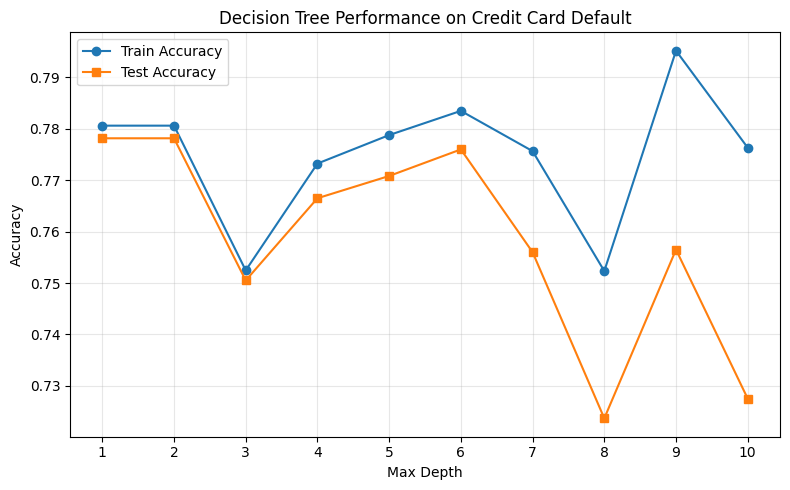


Best test accuracy (depth >= 3) at depth=6: 0.7760


In [62]:
train_accuracies = []
test_accuracies  = []
 
for depth in range(1, 11):
    clf = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",   # counteracts 78/22 class imbalance
        random_state=RANDOM_STATE,
    )
    clf.fit(X_train, y_train)
 
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf.predict(X_test))
 
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
 
    print(f"depth={depth:2d}  train={train_acc:.4f}  test={test_acc:.4f}")
 
# Figure 2: Train vs. Test Accuracy (same style as Week 12)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 11), train_accuracies, marker="o", label="Train Accuracy")
ax.plot(range(1, 11), test_accuracies,  marker="s", label="Test Accuracy")
ax.set_xlabel("Max Depth")
ax.set_ylabel("Accuracy")
ax.set_title("Decision Tree Performance on Credit Card Default")
ax.set_xticks(range(1, 11))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig2_depth_accuracy.png", dpi=150)
plt.show()
 
candidates = [(te, d) for d, te in enumerate(test_accuracies, start=1) if d >= 3]
best_depth = max(candidates)[1]
print(f"\nBest test accuracy (depth >= 3) at depth={best_depth}: {test_accuracies[best_depth-1]:.4f}")


Final model depth=6
Test accuracy: 0.7760


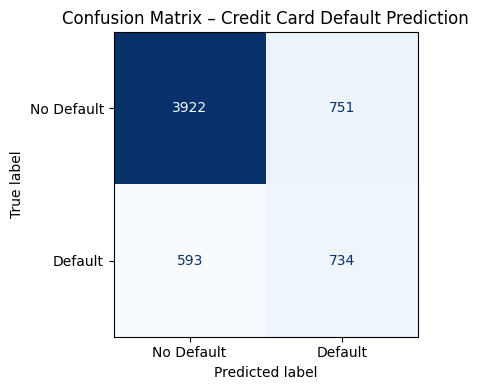


True Negatives  (correct no-default): 3,922
False Positives (flagged but fine)  : 751
False Negatives (missed defaults)   : 593
True Positives  (caught defaults)   : 734


In [66]:
best_clf = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
best_clf.fit(X_train, y_train)
y_pred = best_clf.predict(X_test)
 
print(f"\nFinal model depth={best_depth}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
 
# Figure 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix – Credit Card Default Prediction")
plt.tight_layout()
plt.savefig("fig3_confusion_matrix.png", dpi=150)
plt.show()
 
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correct no-default): {tn:,}")
print(f"False Positives (flagged but fine)  : {fp:,}")
print(f"False Negatives (missed defaults)   : {fn:,}")
print(f"True Positives  (caught defaults)   : {tp:,}")

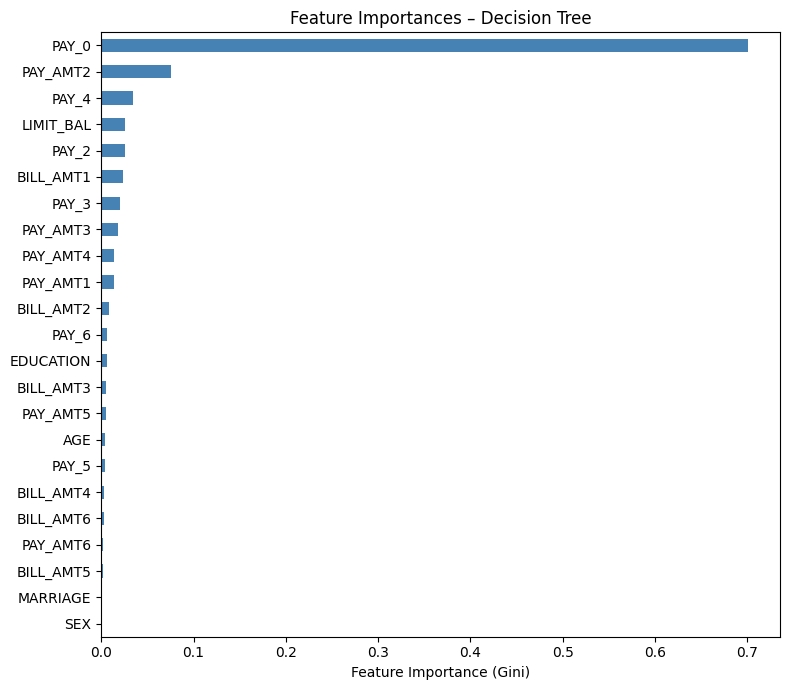


Top 5 features:
PAY_0        0.700382
PAY_AMT2     0.075211
PAY_4        0.034914
LIMIT_BAL    0.026023
PAY_2        0.025718
dtype: float64


In [64]:
importances = pd.Series(best_clf.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=True)
 
fig, ax = plt.subplots(figsize=(8, 7))
importances_sorted.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Feature Importances – Decision Tree")
plt.tight_layout()
plt.savefig("fig4_feature_importances.png", dpi=150)
plt.show()
 
print("\nTop 5 features:")
print(importances.sort_values(ascending=False).head())

In [65]:
importance_df = (
    importances
    .sort_values(ascending=False)
    .reset_index()
)
importance_df.columns = ["Feature", "Importance (Gini)"]
importance_df["Importance (Gini)"] = importance_df["Importance (Gini)"].round(4)
importance_df["Cumulative"] = importance_df["Importance (Gini)"].cumsum().round(4)
importance_df["Rank"] = range(1, len(importance_df) + 1)
importance_df = importance_df[["Rank", "Feature", "Importance (Gini)", "Cumulative"]]
 
print("\nFeature Importances (Gini) – Ranked:")
print(importance_df.to_string(index=False))


Feature Importances (Gini) – Ranked:
 Rank   Feature  Importance (Gini)  Cumulative
    1     PAY_0             0.7004      0.7004
    2  PAY_AMT2             0.0752      0.7756
    3     PAY_4             0.0349      0.8105
    4 LIMIT_BAL             0.0260      0.8365
    5     PAY_2             0.0257      0.8622
    6 BILL_AMT1             0.0235      0.8857
    7     PAY_3             0.0203      0.9060
    8  PAY_AMT3             0.0179      0.9239
    9  PAY_AMT4             0.0141      0.9380
   10  PAY_AMT1             0.0135      0.9515
   11 BILL_AMT2             0.0084      0.9599
   12     PAY_6             0.0059      0.9658
   13 EDUCATION             0.0058      0.9716
   14 BILL_AMT3             0.0055      0.9771
   15  PAY_AMT5             0.0048      0.9819
   16       AGE             0.0045      0.9864
   17     PAY_5             0.0042      0.9906
   18 BILL_AMT4             0.0031      0.9937
   19 BILL_AMT6             0.0028      0.9965
   20  PAY_AMT6       

In [71]:
X_test_df = X_test.copy()
X_test_df["true_label"] = y_test.values
X_test_df["predicted"]  = y_pred
X_test_df["error_type"] = X_test_df.apply(
    lambda r: "False Positive" if r["predicted"] == 1 else "False Negative", axis=1
)
 
wrong = X_test_df[X_test_df["true_label"] != X_test_df["predicted"]]
print(f"\nTotal misclassifications: {len(wrong):,} / {len(X_test_df):,}")
print(wrong["error_type"].value_counts())
 
display_cols = [
    "LIMIT_BAL", "AGE", "EDUCATION", "PAY_0", "PAY_2", "PAY_4", "PAY_6",
    "BILL_AMT1", "PAY_AMT1", "true_label", "predicted", "error_type"
]
 
fp_samples = wrong[wrong["error_type"] == "False Positive"]
fn_samples = wrong[wrong["error_type"] == "False Negative"]
 
sample_fn = fn_samples.sample(3, random_state=1)[display_cols]
sample_fp = fp_samples.sample(2, random_state=2)[display_cols]
five_errors = pd.concat([sample_fn, sample_fp]).reset_index(drop=True)
five_errors.index = five_errors.index + 1
 
print("\n5 Misclassified Samples:")
print(five_errors.to_string())


Total misclassifications: 1,344 / 6,000
error_type
False Positive    751
False Negative    593
Name: count, dtype: int64

5 Misclassified Samples:
   LIMIT_BAL  AGE  EDUCATION  PAY_0  PAY_2  PAY_4  PAY_6  BILL_AMT1  PAY_AMT1  true_label  predicted      error_type
1     150000   44          2     -1     -1     -1     -1        390      5104           1          0  False Negative
2     250000   49          3     -1     -1     -1     -1        632         0           1          0  False Negative
3     210000   29          2      0      0      0      0     209807      5088           1          0  False Negative
4      20000   44          2      1      2      2      0      18330         0           0          1  False Positive
5      50000   29          2      1     -1     -1     -1          0         0           0          1  False Positive
